In [1]:
# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 1 — Install Dependencies
# # ─────────────────────────────────────────────────────────────────────────────
# !pip install torch scikit-learn joblib fastapi uvicorn nest-asyncio pyngrok pandas numpy xgboost openpyxl matplotlib --quiet

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device       : {device}")
print(f"✅ PyTorch      : {torch.__version__}")
print(f"✅ All imports  : OK")

✅ Device       : cpu
✅ PyTorch      : 2.10.0+cpu
✅ All imports  : OK


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load Raw Data Files
# ─────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("universities_synced_with_location.csv")
df_raw = df_raw.rename(columns=lambda x: x.strip())

print(f"✅ US Universities loaded : {df_raw.shape}")
print(f"   Columns : {df_raw.columns.tolist()}")

qs_raw = pd.read_excel("2026 QS World University Rankings 1.3 (For qs.com).xlsx", header=None)

# Detect header row dynamically
header_row = next(
    (i for i in range(len(qs_raw)) if "Rank" in qs_raw.iloc[i].astype(str).tolist()),
    None
)
print(f"\n✅ QS Rankings loaded")
print(f"   Header found at row : {header_row}")

qs_df = qs_raw.iloc[header_row:].copy()
qs_df.columns = qs_df.iloc[0]
qs_df = qs_df.iloc[1:].reset_index(drop=True)
print(f"   QS columns : {qs_df.columns.tolist()}")

✅ US Universities loaded : (2028, 21)
   Columns : ['University', 'City', 'State', 'Location', 'SAT_Min', 'SAT_Max', 'SAT_Avg', 'ACT_Min', 'ACT_Max', 'ACT_Avg', 'Tuition_USD', 'Institution_Type', 'Deadline', 'Average_GPA', 'TOEFL_Min', 'IELTS_Min', 'Scholarship_Mentioned', 'Scholarship_Amount_Examples', 'Scholarship_Percentages', 'URL', 'GPA_Min']

✅ QS Rankings loaded
   Header found at row : 2
   QS columns : ['Index', 'Rank', 'Previous Rank', 'Name', 'Country/Territory', 'Region', 'Size', 'Focus', 'Research', 'Status', 'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK', 'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK', 'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK', 'ISD SCORE', 'ISD RANK', 'IRN SCORE', 'IRN RANK', 'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK', 'Overall SCORE']


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Parse & Merge QS Rankings
# ─────────────────────────────────────────────────────────────────────────────
# Identify the university name column
name_col = next(
    (c for c in qs_df.columns
     if str(c).strip().lower() in ["name", "institution name", "institution"]),
    qs_df.columns[1]
)
qs_df = qs_df[["Rank", name_col]].rename(columns={name_col: "qs_name"})

# Keep only rows with at least one digit in Rank
qs_df = qs_df[qs_df["Rank"].astype(str).str.contains(r"\d", na=False)].copy()

# Strip "=" from tied ranks, take lower bound of banded ranks (e.g. "801-1000" → 801)
qs_df["Rank"] = qs_df["Rank"].astype(str).str.replace("=", "", regex=False).str.strip()
qs_df["Rank"] = qs_df["Rank"].apply(
    lambda x: int(str(x).split("-")[0]) if "-" in str(x) else x
)
qs_df["Rank"] = pd.to_numeric(qs_df["Rank"], errors="coerce")
qs_df = qs_df.dropna(subset=["Rank"])
qs_df["Rank"] = qs_df["Rank"].astype(int)

# Normalize names for matching
qs_df["qs_name_norm"] = qs_df["qs_name"].str.strip().str.lower()
df_raw["uni_norm"]    = df_raw["University"].str.strip().str.lower()

# Merge on normalized name
merged = df_raw.merge(
    qs_df[["qs_name_norm", "Rank"]].rename(columns={"qs_name_norm": "uni_norm"}),
    on="uni_norm", how="left"
)

merged["qs_rank"] = merged["Rank"].fillna(1200).astype(int)
merged.drop(columns=["Rank", "uni_norm"], inplace=True)

matched = (merged["qs_rank"] < 1200).sum()
print(f"✅ QS Merge complete")
print(f"   Matched    : {matched} / {len(merged)} universities")
print(f"   Rank range : {merged['qs_rank'].min()} – {merged['qs_rank'].max()}")

✅ QS Merge complete
   Matched    : 76 / 2028 universities
   Rank range : 1 – 1201


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Data Cleaning & Preprocessing
# ─────────────────────────────────────────────────────────────────────────────
df_uni = merged.copy()

num_cols = [
    "SAT_Min", "SAT_Max", "SAT_Avg",
    "ACT_Min", "ACT_Max", "ACT_Avg",
    "Tuition_USD", "Average_GPA", "GPA_Min",
    "TOEFL_Min", "IELTS_Min",
    "Scholarship_Mentioned"
]
for col in num_cols:
    if col in df_uni.columns:
        df_uni[col] = pd.to_numeric(df_uni[col], errors="coerce")

# ── GPA columns ──────────────────────────────────────────────────────────────
# GPA_Min  : the MINIMUM GPA required for admission (new column you added)
# Average_GPA : the average GPA of admitted students (already existed)
#
# If GPA_Min is missing for a row, we estimate it as 0.25 below Average_GPA,
# which is a realistic approximation (most universities admit slightly below avg).
# Both are capped at 4.0.

df_uni["Average_GPA"] = df_uni["Average_GPA"].fillna(3.0).clip(upper=4.0)

if "GPA_Min" in df_uni.columns:
    # Fill missing GPA_Min using Average_GPA - 0.25 as a safe estimate
    df_uni["GPA_Min"] = df_uni["GPA_Min"].fillna(
        (df_uni["Average_GPA"] - 0.25).clip(lower=1.0)
    ).clip(upper=4.0)
else:
    # GPA_Min column doesn't exist yet — create it from Average_GPA
    # This will be replaced once you add the real column to the dataset
    print("⚠️  GPA_Min column not found — estimating as Average_GPA - 0.25")
    df_uni["GPA_Min"] = (df_uni["Average_GPA"] - 0.25).clip(lower=1.0, upper=4.0)

# ── Other numeric defaults ────────────────────────────────────────────────────
df_uni["SAT_Min"]     = df_uni["SAT_Min"].fillna(900)
df_uni["SAT_Avg"]     = df_uni["SAT_Avg"].fillna(1100)
df_uni["ACT_Min"]     = df_uni["ACT_Min"].fillna(18)
df_uni["ACT_Avg"]     = df_uni["ACT_Avg"].fillna(24)
df_uni["TOEFL_Min"]   = df_uni["TOEFL_Min"].fillna(79)
df_uni["IELTS_Min"]   = df_uni["IELTS_Min"].fillna(6.0)
df_uni["Tuition_USD"] = df_uni["Tuition_USD"].fillna(df_uni["Tuition_USD"].median())
df_uni["Scholarship_Mentioned"] = df_uni["Scholarship_Mentioned"].fillna(0)

df_uni["scholarship_available"] = (df_uni["Scholarship_Mentioned"] > 0).astype(int)
df_uni["country"]          = "USA"
df_uni["institution_type"] = df_uni["Institution_Type"].fillna("University").str.strip()

# ── Remove duplicate universities (keep best QS rank) ────────────────────────
before = len(df_uni)
df_uni["uni_key"] = df_uni["University"].str.strip().str.lower()
df_uni = df_uni.sort_values("qs_rank").drop_duplicates(subset="uni_key").drop(columns="uni_key")
df_uni = df_uni.reset_index(drop=True)
print(f"   Duplicates removed : {before - len(df_uni)}")

# ── Filter out non-university institutions ────────────────────────────────────
INSTITUTION_BLOCKLIST_KEYWORDS = [
    "cosmetology", "barber", "beauty", "vocational", "technical institute",
    "community college", "junior college", "career college", "trade school",
    "culinary", "massage", "esthetics", "nail technician", "aviation academy",
    "bible college", "seminary", "theological", "divinity",
]

def is_valid_university(row) -> bool:
    name     = str(row.get("University", "")).lower()
    inst     = str(row.get("Institution_Type", "")).lower()
    combined = name + " " + inst
    return not any(kw in combined for kw in INSTITUTION_BLOCKLIST_KEYWORDS)

before_filter = len(df_uni)
df_uni = df_uni[df_uni.apply(is_valid_university, axis=1)].reset_index(drop=True)

print(f"✅ Cleaning complete")
print(f"   Final university count   : {len(df_uni)}")
print(f"   Non-university filtered  : {before_filter - len(df_uni)}")
print(f"   Scholarship unis         : {df_uni['scholarship_available'].sum()}")
print(f"\n   GPA column check:")
print(f"   GPA_Min    — min: {df_uni['GPA_Min'].min():.2f}  max: {df_uni['GPA_Min'].max():.2f}  mean: {df_uni['GPA_Min'].mean():.2f}")
print(f"   Average_GPA — min: {df_uni['Average_GPA'].min():.2f}  max: {df_uni['Average_GPA'].max():.2f}  mean: {df_uni['Average_GPA'].mean():.2f}")

   Duplicates removed : 0
✅ Cleaning complete
   Final university count   : 1239
   Non-university filtered  : 789
   Scholarship unis         : 1229

   GPA column check:
   GPA_Min    — min: 0.00  max: 3.70  mean: 2.57
   Average_GPA — min: 2.35  max: 4.00  mean: 3.16


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — University-Level Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────

# ── QS Rank features ─────────────────────────────────────────────────────────
df_uni["qs_rank"] = pd.to_numeric(df_uni["qs_rank"], errors="coerce").fillna(1500)
rank_max = df_uni["qs_rank"].max()

# Continuous prestige score: 1 = best ranked, 0 = worst
df_uni["rank_score"] = (1.0 - (df_uni["qs_rank"] / rank_max)).clip(0, 1)

# Ordinal tier using hard cutoffs (stable — no qcut issues with duplicate ranks)
def assign_rank_tier(rank):
    if   rank <= 100:  return 1   # elite
    elif rank <= 300:  return 2
    elif rank <= 600:  return 3
    elif rank <= 1000: return 4
    else:              return 5   # accessible

df_uni["rank_tier"] = df_uni["qs_rank"].apply(assign_rank_tier).astype(int)

# ── Strictness score ──────────────────────────────────────────────────────────
# Uses GPA_Min (minimum required) not Average_GPA, so it reflects actual bar,
# not how good the average admitted student is.
df_uni["strictness_score"] = (
    (df_uni["GPA_Min"].fillna(0)   / 4.0)   * 0.35 +
    (df_uni["IELTS_Min"].fillna(0) / 9.0)   * 0.20 +
    (df_uni["TOEFL_Min"].fillna(0) / 120.0) * 0.20 +
    (df_uni["SAT_Avg"].fillna(0)   / 1600.0)* 0.15 +
    (df_uni["ACT_Avg"].fillna(0)   / 36.0)  * 0.10
).clip(0, 1)

# ── Affordability score: 1 = cheapest ────────────────────────────────────────
tuition_max = df_uni["Tuition_USD"].max()
df_uni["affordability"] = (1.0 - (df_uni["Tuition_USD"].fillna(tuition_max) / tuition_max)).clip(0, 1)

print("✅ Feature engineering complete")
print(f"   rank_score    : {df_uni['rank_score'].min():.3f} – {df_uni['rank_score'].max():.3f}")
print(f"   rank_tier     : {sorted(df_uni['rank_tier'].unique().tolist())}")
print(f"   strictness    : {df_uni['strictness_score'].min():.3f} – {df_uni['strictness_score'].max():.3f}")
print(f"   affordability : {df_uni['affordability'].min():.3f} – {df_uni['affordability'].max():.3f}")

display(df_uni[[
    "University", "qs_rank", "GPA_Min", "Average_GPA",
    "rank_score", "rank_tier", "strictness_score", "affordability"
]].head(8))

✅ Feature engineering complete
   rank_score    : 0.000 – 0.999
   rank_tier     : [1, 2, 3, 4, 5]
   strictness    : 0.425 – 0.885
   affordability : 0.000 – 0.992


,University,qs_rank,GPA_Min,Average_GPA,rank_score,rank_tier,strictness_score,affordability
0,Massachusetts Institute of Technology (MIT),1,3.5,4.00,0.999167,1,0.842292,0.170596
1,Stanford University,3,3.5,4.00,0.997502,1,0.867292,0.133148
2,Harvard University,5,3.5,4.00,0.995837,1,0.858958,0.177531
3,California Institute of Technology (Caltech),10,3.7,4.00,0.991674,1,0.824688,0.122053
4,University of Chicago,13,3.3,4.00,0.989176,1,0.856458,0.011096
5,University of Pennsylvania,15,3.5,3.90,0.987510,1,0.867292,0.123440
6,Cornell University,16,3.5,3.90,0.986678,1,0.867292,0.011096
7,Yale University,21,3.5,3.95,0.982515,1,0.865417,0.030513


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Synthetic Training Data Generation
#
# Uses GPA_Min as the hard requirement threshold for eligibility labels.
# Average_GPA is kept as a context feature (tells model how competitive
# the average admitted student is, not just whether you clear the bar).
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
N_SAMPLES = 60_000

def generate_synthetic_dataset(df_uni, n=60_000):
    records = []

    for _ in range(n):
        uni = df_uni.sample(1).iloc[0]

        # ── Student profile ───────────────────────────────────────────────────
        cgpa     = float(np.clip(np.random.normal(3.1, 0.4), 1.5, 4.0))
        ielts    = float(np.clip(np.random.normal(6.5, 0.7), 4.0, 9.0))
        toefl    = float(np.clip(np.random.normal(88, 12), 40, 120))

        has_sat  = np.random.random() > 0.35
        sat      = float(np.clip(np.random.normal(1250, 150), 800, 1600)) if has_sat else 0.0
        has_act  = np.random.random() > 0.60
        act      = float(np.clip(np.random.normal(25, 4), 1, 36)) if has_act else 0.0
        has_gre  = np.random.random() > 0.55
        gre      = float(np.clip(np.random.normal(308, 12), 260, 340)) if has_gre else 0.0
        work_exp = int(np.clip(np.random.exponential(1.2), 0, 10))

        # ── Gap features ──────────────────────────────────────────────────────
        # GPA gap uses GPA_Min — the actual admission threshold
        gpa_min_gap  = cgpa  - float(uni["GPA_Min"])
        gpa_avg_gap  = cgpa  - float(uni["Average_GPA"])   # competitive gap
        ielts_gap    = ielts - float(uni["IELTS_Min"])
        toefl_gap    = toefl - float(uni["TOEFL_Min"])
        sat_gap      = (sat  - float(uni["SAT_Avg"])) if has_sat else (800.0 - float(uni["SAT_Avg"]))
        act_gap      = (act  - float(uni["ACT_Avg"])) if has_act else (12.0  - float(uni["ACT_Avg"]))

        # ── Eligibility label (sigmoid-based) ─────────────────────────────────
        def sig(x, s): return 1.0 / (1.0 + np.exp(-x / s))

        # Primary GPA signal uses GPA_Min gap (hard requirement)
        # Secondary uses Average_GPA gap (competitiveness)
        s_gpa  = sig(gpa_min_gap, 0.15) * 0.7 + sig(gpa_avg_gap, 0.20) * 0.3
        s_lang = max(sig(ielts_gap, 0.35), sig(toefl_gap, 4.0))
        s_sat  = sig(sat_gap, 80)  if has_sat else 0.30
        s_act  = sig(act_gap, 2.5) if has_act else 0.30
        s_test = 0.5 * s_sat + 0.5 * s_act

        base_prob = s_gpa * 0.35 + s_lang * 0.30 + s_test * 0.25 + 0.10

        rank = int(uni["qs_rank"])
        if   rank <= 50:  base_prob -= 0.18
        elif rank <= 100: base_prob -= 0.12
        elif rank <= 200: base_prob -= 0.06
        elif rank <= 500: base_prob -= 0.02

        base_prob = np.clip(base_prob, 0.02, 0.95)
        label     = int((base_prob + np.random.normal(0, 0.05)) > 0.50)

        records.append({
            # Student scores
            "CGPA": cgpa, "IELTS": ielts, "TOEFL": toefl,
            "SAT": sat, "ACT": act, "GRE_SCORE": gre,
            "HAS_SAT": int(has_sat), "HAS_ACT": int(has_act), "HAS_GRE": int(has_gre),
            "WORK_EXP": work_exp,
            # Gap features — two GPA gaps (requirement vs. competitiveness)
            "GPA_MIN_GAP":  gpa_min_gap,    # vs hard minimum — most important
            "GPA_AVG_GAP":  gpa_avg_gap,    # vs average admitted student
            "IELTS_GAP":    ielts_gap,
            "TOEFL_GAP":    toefl_gap,
            "SAT_GAP":      sat_gap,
            "ACT_GAP":      act_gap,
            # University context
            "UNI_GPA_MIN":    float(uni["GPA_Min"]),
            "UNI_GPA_AVG":    float(uni["Average_GPA"]),
            "UNI_IELTS":      float(uni["IELTS_Min"]),
            "UNI_TOEFL":      float(uni["TOEFL_Min"]),
            "UNI_SAT_AVG":    float(uni["SAT_Avg"]),
            "UNI_ACT_AVG":    float(uni["ACT_Avg"]),
            "UNI_RANK":       float(uni["qs_rank"]),
            "UNI_RANK_SCORE": float(uni["rank_score"]),
            "UNI_RANK_TIER":  float(uni["rank_tier"]),
            "UNI_STRICTNESS": float(uni["strictness_score"]),
            "UNI_TUITION":    float(uni["Tuition_USD"]),
            "UNI_SCHOLAR":    float(uni["scholarship_available"]),
            "eligible": label,
        })

    return pd.DataFrame(records)


df_train_raw = generate_synthetic_dataset(df_uni, n=N_SAMPLES)
print(f"✅ Synthetic dataset : {df_train_raw.shape}")
print(f"   Positive rate     : {df_train_raw['eligible'].mean():.2%}")
print(f"   Feature columns   : {[c for c in df_train_raw.columns if c != 'eligible']}")

✅ Synthetic dataset : (60000, 29)
   Positive rate     : 83.81%
   Feature columns   : ['CGPA', 'IELTS', 'TOEFL', 'SAT', 'ACT', 'GRE_SCORE', 'HAS_SAT', 'HAS_ACT', 'HAS_GRE', 'WORK_EXP', 'GPA_MIN_GAP', 'GPA_AVG_GAP', 'IELTS_GAP', 'TOEFL_GAP', 'SAT_GAP', 'ACT_GAP', 'UNI_GPA_MIN', 'UNI_GPA_AVG', 'UNI_IELTS', 'UNI_TOEFL', 'UNI_SAT_AVG', 'UNI_ACT_AVG', 'UNI_RANK', 'UNI_RANK_SCORE', 'UNI_RANK_TIER', 'UNI_STRICTNESS', 'UNI_TUITION', 'UNI_SCHOLAR']


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Train / Test Split & Scaling
# ─────────────────────────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df_train_raw.columns if c != "eligible"]

X = df_train_raw[FEATURE_COLS].values.astype(np.float32)
y = df_train_raw["eligible"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Fit scaler on train only — no data leakage
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# Save immediately
joblib.dump(scaler,       "us_scaler.pkl")
joblib.dump(FEATURE_COLS, "us_feature_cols.pkl")

print(f"✅ Split done")
print(f"   Train : {X_train_sc.shape}  |  positive rate: {y_train.mean():.2%}")
print(f"   Test  : {X_test_sc.shape}   |  positive rate: {y_test.mean():.2%}")
print(f"   Scaler saved   → us_scaler.pkl")
print(f"   Features saved → us_feature_cols.pkl")

✅ Split done
   Train : (51000, 28)  |  positive rate: 83.81%
   Test  : (9000, 28)   |  positive rate: 83.81%
   Scaler saved   → us_scaler.pkl
   Features saved → us_feature_cols.pkl


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — XGBoost Classifier Training
# ─────────────────────────────────────────────────────────────────────────────
print("Training XGBoost...")

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators          = 600,
    max_depth             = 6,
    learning_rate         = 0.04,
    subsample             = 0.85,
    colsample_bytree      = 0.85,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_alpha             = 0.05,
    reg_lambda            = 1.5,
    scale_pos_weight      = scale_pos,
    eval_metric           = "auc",
    random_state          = 42,
    tree_method           = "hist",
    device                = "cuda" if torch.cuda.is_available() else "cpu",
    early_stopping_rounds = 30,
)

xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=100
)

xgb_probs = xgb.predict_proba(X_test_sc)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f"\n✅ XGBoost AUC : {xgb_auc:.4f}")

joblib.dump(xgb, "us_xgb_model.pkl")
print(f"   Saved → us_xgb_model.pkl")

Training XGBoost...
[0]	validation_0-auc:0.97013
[100]	validation_0-auc:0.98637
[200]	validation_0-auc:0.98713
[265]	validation_0-auc:0.98712

✅ XGBoost AUC : 0.9872
   Saved → us_xgb_model.pkl


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Residual Neural Network Architecture
# ─────────────────────────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    """Linear → BN → ReLU → Dropout → Linear → BN → skip-add → ReLU"""
    def __init__(self, dim: int, dropout: float = 0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))   # skip connection


class EligibilityResNet(nn.Module):
    """
    Residual eligibility predictor for US university admissions.
    Architecture: InputProj → ResBlock × 2 → Bottleneck → Sigmoid head
    """
    def __init__(self, input_dim: int, hidden_dim: int = 256, dropout: float = 0.25):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
        )
        self.res_block1  = ResidualBlock(hidden_dim, dropout)
        self.res_block2  = ResidualBlock(hidden_dim, dropout)
        self.bottleneck  = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(0.15),
        )
        self.head = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.bottleneck(x)
        return self.head(x)


INPUT_DIM   = len(FEATURE_COLS)
net         = EligibilityResNet(input_dim=INPUT_DIM, hidden_dim=256, dropout=0.25).to(device)
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

print(f"✅ EligibilityResNet initialized on {device}")
print(f"   Input dimension  : {INPUT_DIM}")
print(f"   Trainable params : {total_params:,}")
print(net)

✅ EligibilityResNet initialized on cpu
   Input dimension  : 28
   Trainable params : 289,793
EligibilityResNet(
  (input_proj): Sequential(
    (0): Linear(in_features=28, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
  )
  (res_block1): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.25, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU()
  )
  (res_block2): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Neural Network Training with Checkpointing
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs("checkpoints", exist_ok=True)

X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train,    dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_test_sc,  dtype=torch.float32).to(device)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / max((y_train == 1).sum(), 1)],
    dtype=torch.float32
).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer  = torch.optim.AdamW(net.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

dataset    = torch.utils.data.TensorDataset(X_tr_t, y_tr_t.unsqueeze(1))
loader     = torch.utils.data.DataLoader(dataset, batch_size=2048, shuffle=True)

best_auc, patience_ctr, PATIENCE = 0.0, 0, 5
auc_history = []

print(f"Training EligibilityResNet for up to 150 epochs (patience={PATIENCE})...\n")

for epoch in range(1, 151):
    net.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(net(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    if epoch % 10 == 0:
        net.eval()
        with torch.no_grad():
            preds_val = torch.sigmoid(net(X_te_t)).cpu().numpy().ravel()
        auc = roc_auc_score(y_test, preds_val)
        lr  = scheduler.get_last_lr()[0]
        auc_history.append((epoch, auc))
        print(f"  Epoch {epoch:3d} | AUC: {auc:.4f} | LR: {lr:.6f} | Loss: {epoch_loss/len(loader):.4f}")

        # ── Save checkpoint every 10 epochs ──────────────────────────────────
        torch.save({
            "epoch":      epoch,
            "model_state": net.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "auc":        auc,
        }, f"checkpoints/ckpt_epoch_{epoch:03d}.pt")

        if auc > best_auc:
            best_auc     = auc
            patience_ctr = 0
            # Save best separately
            torch.save(net.state_dict(), "us_best_net.pt")
            print(f"  ⭐ New best AUC → us_best_net.pt")
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

net.load_state_dict(torch.load("us_best_net.pt", map_location=device))
net.eval()
print(f"\n✅ Best Neural Net AUC : {best_auc:.4f}")
print(f"   Weights saved      → us_best_net.pt")
print(f"   Checkpoints saved  → checkpoints/")

Training EligibilityResNet for up to 150 epochs (patience=5)...

  Epoch  10 | AUC: 0.9857 | LR: 0.002927 | Loss: 0.0510
  ⭐ New best AUC → us_best_net.pt
  Epoch  20 | AUC: 0.9861 | LR: 0.002714 | Loss: 0.0478
  ⭐ New best AUC → us_best_net.pt
  Epoch  30 | AUC: 0.9867 | LR: 0.002384 | Loss: 0.0451
  ⭐ New best AUC → us_best_net.pt
  Epoch  40 | AUC: 0.9866 | LR: 0.001967 | Loss: 0.0437
  Epoch  50 | AUC: 0.9863 | LR: 0.001505 | Loss: 0.0420
  Epoch  60 | AUC: 0.9864 | LR: 0.001043 | Loss: 0.0405
  Epoch  70 | AUC: 0.9858 | LR: 0.000626 | Loss: 0.0391
  Epoch  80 | AUC: 0.9860 | LR: 0.000296 | Loss: 0.0380
  Early stopping at epoch 80.

✅ Best Neural Net AUC : 0.9867
   Weights saved      → us_best_net.pt
   Checkpoints saved  → checkpoints/


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Ensemble Evaluation & Model Comparison Report
# ─────────────────────────────────────────────────────────────────────────────
net.eval()
with torch.no_grad():
    nn_probs = torch.sigmoid(net(X_te_t)).cpu().numpy().ravel()

xgb_probs      = xgb.predict_proba(X_test_sc)[:, 1]
ensemble_probs  = 0.40 * nn_probs + 0.60 * xgb_probs
ensemble_preds  = (ensemble_probs >= 0.50).astype(int)

nn_auc         = roc_auc_score(y_test, nn_probs)
xgb_auc_final  = roc_auc_score(y_test, xgb_probs)
ens_auc        = roc_auc_score(y_test, ensemble_probs)

print("=" * 58)
print("           MODEL PERFORMANCE SUMMARY")
print("=" * 58)
print(f"  Residual Neural Net  AUC  :  {nn_auc:.4f}")
print(f"  XGBoost              AUC  :  {xgb_auc_final:.4f}")
print(f"  ENSEMBLE (40/60)     AUC  :  {ens_auc:.4f}  ← PRODUCTION MODEL")
print("=" * 58)
print("\nEnsemble Classification Report:")
print(classification_report(
    y_test, ensemble_preds,
    target_names=["Not Eligible", "Eligible"]
))

           MODEL PERFORMANCE SUMMARY
  Residual Neural Net  AUC  :  0.9867
  XGBoost              AUC  :  0.9872
  ENSEMBLE (40/60)     AUC  :  0.9875  ← PRODUCTION MODEL

Ensemble Classification Report:
              precision    recall  f1-score   support

Not Eligible       0.72      0.96      0.82      1457
    Eligible       0.99      0.93      0.96      7543

    accuracy                           0.93      9000
   macro avg       0.85      0.94      0.89      9000
weighted avg       0.95      0.93      0.94      9000



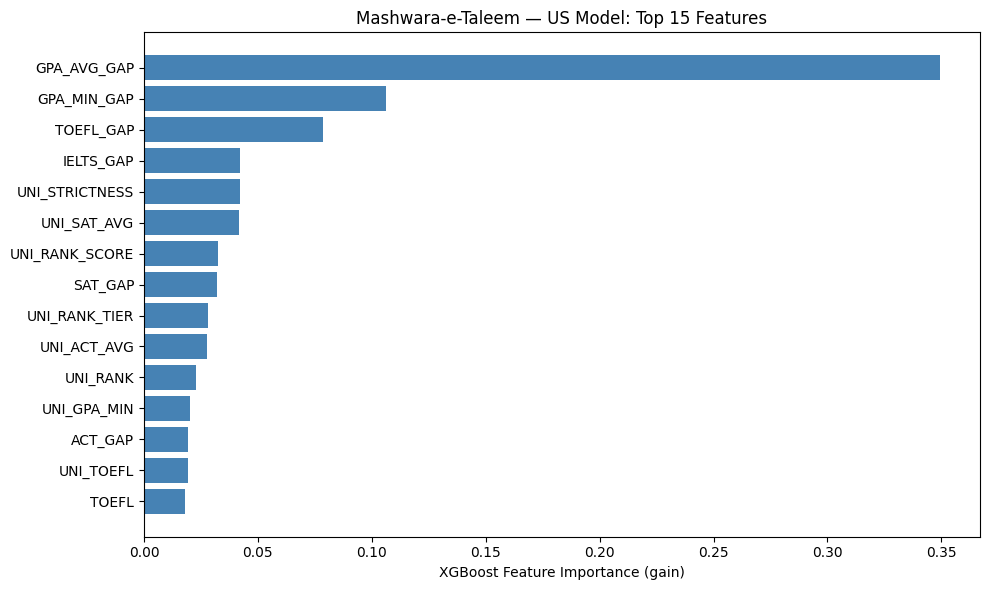


✅ Plot saved → us_feature_importance.png

Top 5 most important features:
   GPA_AVG_GAP                importance = 0.3495
   GPA_MIN_GAP                importance = 0.1062
   TOEFL_GAP                  importance = 0.0784
   IELTS_GAP                  importance = 0.0423
   UNI_STRICTNESS             importance = 0.0420


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — XGBoost Feature Importance (Top 15)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fi_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="steelblue")
plt.xlabel("XGBoost Feature Importance (gain)")
plt.title("Mashwara-e-Taleem — US Model: Top 15 Features")
plt.tight_layout()
plt.savefig("us_feature_importance.png", dpi=150)
plt.show()

print("\n✅ Plot saved → us_feature_importance.png")
print("\nTop 5 most important features:")
for _, row in fi_df.head(5).iterrows():
    print(f"   {row['feature']:25s}  importance = {row['importance']:.4f}")

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Reload All Artifacts (run this if kernel restarts)
# ─────────────────────────────────────────────────────────────────────────────
scaler       = joblib.load("us_scaler.pkl")
FEATURE_COLS = joblib.load("us_feature_cols.pkl")
xgb          = joblib.load("us_xgb_model.pkl")
net.load_state_dict(torch.load("us_best_net.pt", map_location=device))
net.eval()

print(f"✅ All artifacts reloaded")
print(f"   Feature cols  : {len(FEATURE_COLS)}")
print(f"   Universities  : {len(df_uni)}")
print(f"   Device        : {device}")

✅ All artifacts reloaded
   Feature cols  : 28
   Universities  : 1239
   Device        : cpu


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Input Validation, Feature Builder & Improvement Advisor
# ─────────────────────────────────────────────────────────────────────────────

SCORE_BOUNDS = {
    "IELTS":     (0.0, 9.0),
    "TOEFL":     (0,   120),
    "SAT":       (0,   1600),
    "ACT":       (0,   36),
    "GRE_SCORE": (0,   340),
    "WORK_EXP":  (0,   40),
    "CGPA":      (0.0, 4.0),
}

TIER_ORDER = {"✅ Safe": 0, "🎯 Match": 1, "🌟 Dream": 2, "❌ Unlikely": 3}

RANK_DIFFICULTY_PENALTY = {1: 0.20, 2: 0.12, 3: 0.06, 4: 0.02, 5: 0.0}


def validate_and_clamp(user: dict) -> dict:
    """
    Validates input bounds. 0 = test not taken for optional fields.
    CGPA must be > 0. DUOLINGO silently ignored if passed.
    """
    cleaned, errors = dict(user), []
    cleaned.pop("DUOLINGO", None)   # not used — dataset has no DUOLINGO minimum

    for field, (lo, hi) in SCORE_BOUNDS.items():
        if field not in cleaned:
            continue
        val = float(cleaned[field])

        if field == "CGPA" and val <= 0:
            errors.append("CGPA must be greater than 0")
            continue

        if val < lo or val > hi:
            errors.append(f"{field} must be between {lo} and {hi} (got {val})")

        cleaned[field] = max(lo, min(hi, val))

    if errors:
        raise ValueError(" | ".join(errors))

    return cleaned


def build_feature_row(stu: dict, uni: pd.Series) -> np.ndarray:
    """
    Build a feature vector for a (student, university) pair.
    Uses GPA_Min for the hard requirement gap and Average_GPA for
    the competitiveness gap — both matter for realistic predictions.
    """
    sat = float(stu.get("SAT", 0))
    act = float(stu.get("ACT", 0))
    gre = float(stu.get("GRE_SCORE", 0))

    has_sat = int(sat > 0)
    has_act = int(act > 0)
    has_gre = int(gre > 0)

    sat_gap = (sat - float(uni["SAT_Avg"])) if has_sat else (800.0 - float(uni["SAT_Avg"]))
    act_gap = (act - float(uni["ACT_Avg"])) if has_act else (12.0  - float(uni["ACT_Avg"]))

    row = {
        "CGPA":           float(stu["CGPA"]),
        "IELTS":          float(stu.get("IELTS", 0)),
        "TOEFL":          float(stu.get("TOEFL", 0)),
        "DUOLINGO":       0.0,       # kept for model vector compatibility, always 0
        "SAT":            sat,
        "ACT":            act,
        "GRE_SCORE":      gre,
        "HAS_SAT":        has_sat,
        "HAS_ACT":        has_act,
        "HAS_GRE":        has_gre,
        "WORK_EXP":       float(stu.get("WORK_EXP", 0)),
        # Two GPA gaps — hard requirement + competitiveness
        "GPA_MIN_GAP":    float(stu["CGPA"]) - float(uni["GPA_Min"]),
        "GPA_AVG_GAP":    float(stu["CGPA"]) - float(uni["Average_GPA"]),
        "IELTS_GAP":      float(stu.get("IELTS", 0)) - float(uni["IELTS_Min"]),
        "TOEFL_GAP":      float(stu.get("TOEFL", 0)) - float(uni["TOEFL_Min"]),
        "SAT_GAP":        sat_gap,
        "ACT_GAP":        act_gap,
        # University context
        "UNI_GPA_MIN":    float(uni["GPA_Min"]),
        "UNI_GPA_AVG":    float(uni["Average_GPA"]),
        "UNI_IELTS":      float(uni["IELTS_Min"]),
        "UNI_TOEFL":      float(uni["TOEFL_Min"]),
        "UNI_SAT_AVG":    float(uni["SAT_Avg"]),
        "UNI_ACT_AVG":    float(uni["ACT_Avg"]),
        "UNI_RANK":       float(uni["qs_rank"]),
        "UNI_RANK_SCORE": float(uni["rank_score"]),
        "UNI_RANK_TIER":  float(uni["rank_tier"]),
        "UNI_STRICTNESS": float(uni["strictness_score"]),
        "UNI_TUITION":    float(uni["Tuition_USD"]),
        "UNI_SCHOLAR":    float(uni["scholarship_available"]),
    }
    return np.array([row[f] for f in FEATURE_COLS], dtype=np.float32)


def get_missing_requirements(stu: dict, uni: pd.Series) -> list:
    """
    Hard requirement gaps only.
    GPA check uses GPA_Min (not Average_GPA) — that is the actual admission bar.
    Language gap only flagged if BOTH IELTS and TOEFL are below requirement.
    """
    gaps = []

    # ── GPA: use GPA_Min as the hard threshold ────────────────────────────────
    if float(stu["CGPA"]) < float(uni["GPA_Min"]):
        gaps.append(
            f"CGPA {stu['CGPA']:.2f} < minimum required {uni['GPA_Min']:.2f}"
        )

    # ── Language ──────────────────────────────────────────────────────────────
    ielts = float(stu.get("IELTS", 0))
    toefl = float(stu.get("TOEFL", 0))

    ielts_ok = ielts > 0 and ielts >= float(uni["IELTS_Min"])
    toefl_ok = toefl > 0 and toefl >= float(uni["TOEFL_Min"])

    if not ielts_ok and not toefl_ok:
        if ielts > 0 or toefl > 0:
            gaps.append(
                f"Language test below requirement — "
                f"need IELTS ≥ {uni['IELTS_Min']} or TOEFL ≥ {uni['TOEFL_Min']}"
            )
        else:
            gaps.append(
                f"No English test on record — "
                f"need IELTS ≥ {uni['IELTS_Min']} or TOEFL ≥ {uni['TOEFL_Min']}"
            )

    # ── SAT / ACT ─────────────────────────────────────────────────────────────
    sat = float(stu.get("SAT", 0))
    act = float(stu.get("ACT", 0))
    if sat > 0 and sat < float(uni["SAT_Min"]):
        gaps.append(f"SAT {int(sat)} < minimum {int(uni['SAT_Min'])}")
    if act > 0 and act < float(uni["ACT_Min"]):
        gaps.append(f"ACT {int(act)} < minimum {int(uni['ACT_Min'])}")

    return gaps


def effective_gap_count(gaps: list) -> int:
    lang_gaps  = [g for g in gaps if "Language" in g or "English" in g]
    other_gaps = [g for g in gaps if g not in lang_gaps]
    return len(other_gaps) + (1 if lang_gaps else 0)


def classify_tier(prob: float, gaps: list, rank_tier: int) -> str:
    """Tier depends on probability AND prestige. Elite unis require higher adj_prob."""
    n_eff    = effective_gap_count(gaps)
    penalty  = RANK_DIFFICULTY_PENALTY.get(int(rank_tier), 0.0)
    adj_prob = prob - penalty

    if   adj_prob >= 0.60 and n_eff == 0: return "✅ Safe"
    elif adj_prob >= 0.38:                 return "🎯 Match"
    elif adj_prob >= 0.18 and n_eff <= 1:  return "🌟 Dream"
    else:                                  return "❌ Unlikely"


def generate_improvement_tips(stu: dict, uni: pd.Series, gaps: list, prob: float) -> list:
    """
    Personalised tips. GPA tip now uses GPA_Min as the hard bar
    and Average_GPA as the competitive target.
    SAT/ACT tips suppressed for graduate profiles.
    """
    tips     = []
    cgpa     = float(stu["CGPA"])
    gpa_min  = float(uni["GPA_Min"])
    gpa_avg  = float(uni["Average_GPA"])
    ielts    = float(stu.get("IELTS", 0))
    toefl    = float(stu.get("TOEFL", 0))
    sat      = float(stu.get("SAT", 0))
    act      = float(stu.get("ACT", 0))
    gre      = float(stu.get("GRE_SCORE", 0))
    work_exp = int(stu.get("WORK_EXP", 0))

    is_grad_profile = gre > 0 or work_exp >= 1

    # ── GPA ───────────────────────────────────────────────────────────────────
    if cgpa < gpa_min:
        # Below hard minimum — critical gap
        tips.append(
            f"📈 Your CGPA ({cgpa:.2f}) is below the minimum required ({gpa_min:.2f}). "
            f"You need to raise it by at least {round(gpa_min - cgpa, 2)} points "
            f"to be considered for admission."
        )
    elif cgpa < gpa_avg:
        # Cleared minimum but below average admitted student
        tips.append(
            f"📊 Your CGPA ({cgpa:.2f}) meets the minimum ({gpa_min:.2f}) but is below "
            f"the average admitted student ({gpa_avg:.2f}). Improving it will make your "
            f"application significantly more competitive."
        )
    elif cgpa < gpa_avg + 0.1:
        # At or just above average — still worth noting
        tips.append(
            f"📊 Your CGPA ({cgpa:.2f}) is right around the average admitted student "
            f"({gpa_avg:.2f}). Maintaining this level is good — a strong SOP can compensate."
        )

    # ── Language ─────────────────────────────────────────────────────────────
    ielts_req = float(uni["IELTS_Min"])
    toefl_req = float(uni["TOEFL_Min"])

    if ielts == 0 and toefl == 0:
        tips.append(
            f"🌍 No English proficiency test on record. Take IELTS (target: {ielts_req}+) "
            f"or TOEFL (target: {int(toefl_req)}+) — mandatory for international applicants."
        )
    elif ielts > 0 and ielts < ielts_req:
        tips.append(
            f"🗣️ IELTS {ielts} is below the required {ielts_req}. "
            f"Aim for {ielts_req + 0.5:.1f}+ on your next attempt."
        )
    elif toefl > 0 and toefl < toefl_req:
        tips.append(
            f"🗣️ TOEFL {int(toefl)} is below the required {int(toefl_req)}. "
            f"Aim for {int(toefl_req) + 5}+ on your next attempt."
        )

    # ── SAT / ACT — undergrad only ────────────────────────────────────────────
    if not is_grad_profile:
        sat_avg = float(uni["SAT_Avg"])
        if sat == 0:
            tips.append(
                f"📝 No SAT on record. A score of {int(sat_avg)}+ "
                f"(this university's average) will boost your competitiveness."
            )
        elif sat < float(uni["SAT_Min"]):
            tips.append(
                f"📝 SAT {int(sat)} is below the minimum {int(uni['SAT_Min'])}. "
                f"Target {int(sat_avg)}+ with focused prep."
            )
        elif sat < sat_avg:
            tips.append(
                f"📝 SAT {int(sat)} is {int(sat_avg - sat)} points below this "
                f"university's average ({int(sat_avg)}). A retake would help."
            )

        act_avg = float(uni["ACT_Avg"])
        if act == 0 and sat == 0:
            tips.append(f"📝 Consider taking the ACT (target: {int(act_avg)}+) as a SAT alternative.")
        elif act > 0 and act < float(uni["ACT_Min"]):
            tips.append(
                f"📝 ACT {int(act)} is below the minimum {int(uni['ACT_Min'])}. "
                f"Target {int(act_avg)}+ on your next attempt."
            )

    # ── GRE — grad only ───────────────────────────────────────────────────────
    if is_grad_profile:
        if gre == 0:
            tips.append(
                f"🎓 No GRE on record. For graduate programs, 310+ is recommended. "
                f"Top US universities expect 315+ for competitive applicants."
            )
        elif gre < 310:
            tips.append(
                f"🎓 GRE {int(gre)} is below the competitive threshold of 310. "
                f"Retake targeting 315+ to unlock stronger programs."
            )

    # ── Work exp — grad only ──────────────────────────────────────────────────
    if is_grad_profile and work_exp == 0:
        tips.append(
            f"💼 1–2 years of relevant work or research experience will "
            f"significantly strengthen your graduate application."
        )

    # ── Scholarship ───────────────────────────────────────────────────────────
    if float(uni["scholarship_available"]) == 0:
        tips.append(
            f"💰 No scholarship data for this university. Explore HEC Overseas, "
            f"Fulbright, or USAID scholarships for Pakistani students."
        )

    # ── Already strong ────────────────────────────────────────────────────────
    if prob >= 0.65 and len(tips) == 0:
        tips.append(
            f"🌟 Strong match. Focus on a compelling Statement of Purpose "
            f"and strong letters of recommendation."
        )

    return tips


def ml_ensemble_prob(feature_row: np.ndarray) -> float:
    """XGBoost + ResNet ensemble → blended probability."""
    row_sc = scaler.transform(feature_row.reshape(1, -1))
    xgb_p  = xgb.predict_proba(row_sc)[0, 1]
    t      = torch.tensor(row_sc, dtype=torch.float32).to(device)
    with torch.no_grad():
        nn_p = torch.sigmoid(net(t)).item()
    return 0.40 * nn_p + 0.60 * xgb_p


print("✅ All inference + improvement functions defined.")
print("   ✔ GPA_Min used for hard admission bar (missing_requirements + tips)")
print("   ✔ Average_GPA used for competitiveness signal (tips + feature vector)")
print("   ✔ DUOLINGO silently dropped — no university minimum in dataset")
print("   ✔ SAT/ACT tips suppressed for graduate profiles")
print("   ✔ Tier: rank-prestige-aware penalty applied")

✅ All inference + improvement functions defined.
   ✔ GPA_Min used for hard admission bar (missing_requirements + tips)
   ✔ Average_GPA used for competitiveness signal (tips + feature vector)
   ✔ DUOLINGO silently dropped — no university minimum in dataset
   ✔ SAT/ACT tips suppressed for graduate profiles
   ✔ Tier: rank-prestige-aware penalty applied


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — recommend_programs() — Main Engine v3.3
# ─────────────────────────────────────────────────────────────────────────────
def recommend_programs(
    input_json:  dict,
    top_k:       int        = 10,
    max_tuition: int | None = None,
    tier_filter: str | None = None,
    min_prob:    float      = 0.08,
) -> list[dict]:
    """
    US University Recommendation Engine — Mashwara-e-Taleem v3.3

    GPA logic:
      - GPA_Min  → hard admission threshold (used in missing_requirements)
      - Average_GPA → competitiveness signal (shown in output as context)
    """
    user    = validate_and_clamp(input_json)
    results = []
    seen    = set()

    for _, uni in df_uni.iterrows():

        if max_tuition and int(max_tuition) > 0:
            if float(uni["Tuition_USD"]) > max_tuition:
                continue

        uni_key = str(uni["University"]).strip().lower()
        if uni_key in seen:
            continue

        feat = build_feature_row(user, uni)
        prob = float(np.clip(ml_ensemble_prob(feat), 0.01, 0.95))

        if prob < min_prob:
            continue

        gaps = get_missing_requirements(user, uni)
        tier = classify_tier(prob, gaps, int(uni["rank_tier"]))
        tips = generate_improvement_tips(user, uni, gaps, prob)

        cgpa_comfort = float(np.clip(
            (user["CGPA"] - float(uni["GPA_Min"])) / 0.4, -1, 1
        ))
        final_score = float(
            0.45 * prob +
            0.40 * float(uni["rank_score"]) +
            0.15 * max(cgpa_comfort, 0)
        )

        seen.add(uni_key)

        results.append({
            "university_name":       str(uni["University"]),
            "country":               "🇺🇸 USA",
            "qs_rank":               int(uni["qs_rank"]),
            "tuition_fee_usd":       int(uni["Tuition_USD"]),
            "scholarship_available": bool(int(uni["scholarship_available"])),
            "eligibility_prob":      round(prob, 4),
            "final_score":           round(final_score, 4),
            "tier":                  tier,
            "tier_order":            TIER_ORDER[tier],
            "missing_requirements":  gaps,
            "how_to_improve":        tips,
            "institution_type":      str(uni.get("Institution_Type", "University")),
            "location":              str(uni.get("Location", "USA")),
            "application_deadline":  str(uni.get("Deadline", "Rolling")),
            "sat_avg":               int(uni["SAT_Avg"]),
            "act_avg":               int(uni["ACT_Avg"]),
            "gpa_minimum":           round(float(uni["GPA_Min"]), 2),
            "gpa_avg_admitted":      round(float(uni["Average_GPA"]), 2),
        })

    # ── Fallback ──────────────────────────────────────────────────────────────
    if not results:
        fallback_seen = set()
        for _, uni in df_uni.iterrows():
            uni_key = str(uni["University"]).strip().lower()
            if uni_key in fallback_seen:
                continue
            if max_tuition and int(max_tuition) > 0:
                if float(uni["Tuition_USD"]) > max_tuition:
                    continue

            feat = build_feature_row(user, uni)
            prob = float(np.clip(ml_ensemble_prob(feat), 0.01, 0.95))
            if prob < 0.05:
                continue

            gaps = get_missing_requirements(user, uni)
            tier = classify_tier(prob, gaps, int(uni["rank_tier"]))
            tips = generate_improvement_tips(user, uni, gaps, prob)
            cgpa_comfort = float(np.clip(
                (user["CGPA"] - float(uni["GPA_Min"])) / 0.4, -1, 1
            ))
            final_score = float(
                0.45 * prob +
                0.40 * float(uni["rank_score"]) +
                0.15 * max(cgpa_comfort, 0)
            )
            fallback_seen.add(uni_key)
            results.append({
                "university_name":       str(uni["University"]),
                "country":               "🇺🇸 USA",
                "qs_rank":               int(uni["qs_rank"]),
                "tuition_fee_usd":       int(uni["Tuition_USD"]),
                "scholarship_available": bool(int(uni["scholarship_available"])),
                "eligibility_prob":      round(prob, 4),
                "final_score":           round(final_score, 4),
                "tier":                  tier,
                "tier_order":            TIER_ORDER[tier],
                "missing_requirements":  gaps,
                "how_to_improve":        tips,
                "institution_type":      str(uni.get("Institution_Type", "University")),
                "location":              str(uni.get("Location", "USA")),
                "application_deadline":  str(uni.get("Deadline", "Rolling")),
                "sat_avg":               int(uni["SAT_Avg"]),
                "act_avg":               int(uni["ACT_Avg"]),
                "gpa_minimum":           round(float(uni["GPA_Min"]), 2),
                "gpa_avg_admitted":      round(float(uni["Average_GPA"]), 2),
                "note":                  "⚠️ Filters relaxed — closest matches to your profile.",
            })

        if not results:
            return [{
                "university_name":       "No universities found even with relaxed filters.",
                "country":               "🇺🇸 USA",
                "qs_rank":               0,
                "tuition_fee_usd":       0,
                "scholarship_available": False,
                "eligibility_prob":      0.0,
                "final_score":           0.0,
                "tier":                  "❌ Unlikely",
                "missing_requirements":  ["Profile is below threshold for all universities in dataset."],
                "how_to_improve": [
                    "📈 Improve CGPA above 2.5 to unlock more options.",
                    "🌍 Take IELTS (target 6.0+) or TOEFL (target 79+) as a minimum.",
                    "📝 Consider taking the SAT — even 1000+ helps significantly.",
                ],
                "institution_type":      "N/A",
                "location":              "N/A",
                "application_deadline":  "N/A",
                "sat_avg":               0,
                "act_avg":               0,
                "gpa_minimum":           0.0,
                "gpa_avg_admitted":      0.0,
                "note":                  "No matches found even after relaxing all filters.",
            }]

    results.sort(key=lambda x: (x["qs_rank"], -x["final_score"]))

    for r in results:
        r.pop("tier_order", None)

    if tier_filter and str(tier_filter).strip():
        results = [r for r in results
                   if str(tier_filter).strip().lower() in r["tier"].lower()]

    return results[:top_k]


print("✅ recommend_programs() v3.3 ready")
print("   ✔ GPA_Min  → hard admission bar (missing_requirements, cgpa_comfort, tips)")
print("   ✔ Average_GPA → shown as 'gpa_avg_admitted' context field in output")
print("   ✔ Output fields: gpa_minimum + gpa_avg_admitted (replaces old expected_gpa)")

✅ recommend_programs() v3.3 ready
   ✔ GPA_Min  → hard admission bar (missing_requirements, cgpa_comfort, tips)
   ✔ Average_GPA → shown as 'gpa_avg_admitted' context field in output
   ✔ Output fields: gpa_minimum + gpa_avg_admitted (replaces old expected_gpa)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Test Case 1: Strong Student
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 1 — STRONG STUDENT: CGPA 3.7 | SAT 1480 | IELTS 7.5 | GRE 320")
print("=" * 70)

results_t1 = recommend_programs({
    "CGPA":      3.7,
    "IELTS":     7.5,
    "TOEFL":     105,
    "SAT":       1480,
    "ACT":       32,
    "GRE_SCORE": 320,
    "WORK_EXP":  2,
}, top_k=10, max_tuition=70000)

df_t1 = pd.DataFrame(results_t1)[[
    "qs_rank", "university_name", "tier", "eligibility_prob",
    "final_score", "tuition_fee_usd", "scholarship_available",
    "gpa_minimum", "gpa_avg_admitted", "missing_requirements"
]]
print(f"Results returned  : {len(results_t1)}")
print(f"Prob range        : {df_t1['eligibility_prob'].min():.3f} – {df_t1['eligibility_prob'].max():.3f}\n")
print(df_t1.to_string(index=False))
print("\n📋 Improvement tips for top result:")
for tip in results_t1[0].get("how_to_improve", []):
    print(f"  {tip}")

TEST 1 — STRONG STUDENT: CGPA 3.7 | SAT 1480 | IELTS 7.5 | GRE 320
Results returned  : 10
Prob range        : 0.084 – 0.905

 qs_rank                              university_name       tier  eligibility_prob  final_score  tuition_fee_usd  scholarship_available  gpa_minimum  gpa_avg_admitted                           missing_requirements
       1  Massachusetts Institute of Technology (MIT) ❌ Unlikely            0.4692       0.6858            59800                   True          3.5              4.00 [SAT 1480 < minimum 1520, ACT 32 < minimum 34]
       3                          Stanford University ❌ Unlikely            0.1331       0.5339            62500                   True          3.5              4.00 [SAT 1480 < minimum 1510, ACT 32 < minimum 34]
       5                           Harvard University ❌ Unlikely            0.3118       0.6136            59300                   True          3.5              4.00 [SAT 1480 < minimum 1510, ACT 32 < minimum 34]
      10 California

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Test Case 2: Average Student
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 2 — AVERAGE STUDENT: CGPA 3.0 | SAT 1150 | IELTS 6.5")
print("=" * 70)

results_t2 = recommend_programs({
    "CGPA":      3.0,
    "IELTS":     6.5,
    "TOEFL":     85,
    "SAT":       1150,
    "ACT":       24,
    "GRE_SCORE": 0,
    "WORK_EXP":  0,
}, top_k=10, max_tuition=45000)

df_t2 = pd.DataFrame(results_t2)[[
    "qs_rank", "university_name", "tier", "eligibility_prob",
    "final_score", "tuition_fee_usd", "scholarship_available"
]]
print(f"Results returned  : {len(results_t2)}")
print(f"Prob range        : {df_t2['eligibility_prob'].min():.3f} – {df_t2['eligibility_prob'].max():.3f}\n")
print(df_t2.to_string(index=False))
print("\n📋 Improvement tips for top result:")
for tip in results_t2[0].get("how_to_improve", []):
    print(f"  {tip}")

TEST 2 — AVERAGE STUDENT: CGPA 3.0 | SAT 1150 | IELTS 6.5
Results returned  : 10
Prob range        : 0.092 – 0.950

 qs_rank                  university_name       tier  eligibility_prob  final_score  tuition_fee_usd  scholarship_available
     212            University of Florida ❌ Unlikely            0.1442       0.3943            28700                   True
     333                  York University     ✅ Safe            0.9500       0.8103            23000                   True
     449            Iowa State University    🎯 Match            0.5905       0.5162            28900                   True
     465             University of Kansas     ✅ Safe            0.7169       0.5677            30400                   True
     530               University of Iowa    🎯 Match            0.6005       0.4937            33400                   True
     549         Florida State University ❌ Unlikely            0.1091       0.2663            21700                   True
     582 Florida

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Test Case 3: Budget-Constrained Student
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 3 — BUDGET CONSTRAINED: CGPA 3.2 | max tuition $30K | ACT not taken")
print("=" * 70)

results_t3 = recommend_programs({
    "CGPA":      3.2,
    "IELTS":     6.5,
    "TOEFL":     88,
    "SAT":       1200,
    "ACT":       0,
    "GRE_SCORE": 305,
    "WORK_EXP":  1,
}, top_k=10, max_tuition=30000)

df_t3 = pd.DataFrame(results_t3)[[
    "qs_rank", "university_name", "tier", "eligibility_prob",
    "tuition_fee_usd", "scholarship_available", "location"
]]
print(f"Results returned  : {len(results_t3)}")
print(f"Prob range        : {df_t3['eligibility_prob'].min():.3f} – {df_t3['eligibility_prob'].max():.3f}\n")
print(df_t3.to_string(index=False))
print("\n📋 Improvement tips for top result:")
for tip in results_t3[0].get("how_to_improve", []):
    print(f"  {tip}")

TEST 3 — BUDGET CONSTRAINED: CGPA 3.2 | max tuition $30K | ACT not taken
Results returned  : 10
Prob range        : 0.862 – 0.950

 qs_rank                  university_name    tier  eligibility_prob  tuition_fee_usd  scholarship_available        location
     212            University of Florida 🎯 Match            0.8622            28700                   True Gainesville, FL
     333                  York University  ✅ Safe            0.9500            23000                   True        York, NE
     449            Iowa State University  ✅ Safe            0.9500            28900                   True        Ames, IA
     549         Florida State University 🎯 Match            0.9500            21700                   True Tallahassee, FL
     582 Florida International University  ✅ Safe            0.9500            19000                   True       Miami, FL
     654      University of South Florida  ✅ Safe            0.9500            17300                   True       Tampa, FL
 

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Test Case 4: Scholarship Hunter
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 4 — SCHOLARSHIP HUNTER: No SAT/ACT | IELTS 7.0 | CGPA 3.5")
print("=" * 70)

results_t4 = recommend_programs({
    "CGPA":      3.5,
    "IELTS":     7.0,
    "TOEFL":     0,
    "SAT":       0,
    "ACT":       0,
    "GRE_SCORE": 0,
    "WORK_EXP":  0,
}, top_k=10)

results_t4_scholar = [r for r in results_t4 if r["scholarship_available"]]
print(f"Total results    : {len(results_t4)}")
print(f"With scholarship : {len(results_t4_scholar)}\n")

df_t4 = pd.DataFrame(results_t4)[[
    "qs_rank", "university_name", "tier", "eligibility_prob",
    "tuition_fee_usd", "scholarship_available", "gpa_minimum"
]]
print(df_t4.to_string(index=False))
print("\n📋 Improvement tips for top result:")
for tip in results_t4[0].get("how_to_improve", []):
    print(f"  {tip}")

TEST 4 — SCHOLARSHIP HUNTER: No SAT/ACT | IELTS 7.0 | CGPA 3.5
Total results    : 10
With scholarship : 10

 qs_rank                 university_name       tier  eligibility_prob  tuition_fee_usd  scholarship_available  gpa_minimum
      88               Boston University    🌟 Dream            0.4020            60000                   True          3.0
     110 University of Wisconsin-Madison    🎯 Match            0.5494            38100                   True          3.0
     119                 Rice University ❌ Unlikely            0.2133            56400                   True          3.0
     161       Michigan State University    🎯 Match            0.6845            43800                   True          3.0
     182                Emory University ❌ Unlikely            0.2762            58600                   True          3.0
     212           University of Florida     ✅ Safe            0.7550            28700                   True          3.0
     250           Vanderbilt U

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Test Case 5: Dream Tier Filter
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 5 — DREAM TIER: CGPA 3.3 | SAT 1350 | IELTS 7.0")
print("=" * 70)

results_t5 = recommend_programs({
    "CGPA":      3.3,
    "IELTS":     7.0,
    "TOEFL":     95,
    "SAT":       1350,
    "ACT":       29,
    "GRE_SCORE": 312,
    "WORK_EXP":  1,
}, top_k=10, tier_filter="Dream")

if results_t5 and results_t5[0]["university_name"] != "No universities found even with relaxed filters.":
    df_t5 = pd.DataFrame(results_t5)[[
        "qs_rank", "university_name", "tier", "eligibility_prob",
        "final_score", "tuition_fee_usd",
        "gpa_minimum", "gpa_avg_admitted", "missing_requirements"
    ]]
    print(f"Dream-tier results : {len(results_t5)}\n")
    print(df_t5.to_string(index=False))
    print("\n📋 How to make these dream schools a reality:")
    for tip in results_t5[0].get("how_to_improve", []):
        print(f"  {tip}")
else:
    print("No Dream-tier matches for this profile under these filters.")

TEST 5 — DREAM TIER: CGPA 3.3 | SAT 1350 | IELTS 7.0
Dream-tier results : 6

 qs_rank                              university_name    tier  eligibility_prob  final_score  tuition_fee_usd  gpa_minimum  gpa_avg_admitted  missing_requirements
      46 University of California, Los Angeles (UCLA) 🌟 Dream            0.4163       0.6845            44100          3.0              4.00                    []
     571                     Colorado School of Mines 🌟 Dream            0.3534       0.3689            45800          3.3              3.67                    []
    1200          Rose-Hulman Institute of Technology 🌟 Dream            0.3092       0.1395            58600          3.3              3.71                    []
    1200                       Santa Clara University 🌟 Dream            0.2654       0.1198            61300          3.3              3.76 [ACT 29 < minimum 31]
    1200                          Connecticut College 🌟 Dream            0.2469       0.1115            6720

In [22]:

# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 22 — Launch Server via ngrok (FINAL FIXED)
# # ─────────────────────────────────────────────────────────────────────────────

# !pip install nest_asyncio pyngrok uvicorn fastapi -q

# import nest_asyncio
# from pyngrok import ngrok
# import uvicorn

# # ─────────────────────────────────────────────────────────────────────────────
# # 🔴 ENSURE APP EXISTS
# # ─────────────────────────────────────────────────────────────────────────────
# try:
#     app
# except NameError:
#     print("⚠️ 'app' not found — creating basic FastAPI app")

#     from fastapi import FastAPI
#     app = FastAPI()

#     @app.get("/")
#     def home():
#         return {"message": "Mashwara-e-Taleem API running"}

# # ─────────────────────────────────────────────────────────────────────────────
# # Fix async loop issue
# # ─────────────────────────────────────────────────────────────────────────────
# nest_asyncio.apply()

# # ─────────────────────────────────────────────────────────────────────────────
# # ngrok setup
# # ─────────────────────────────────────────────────────────────────────────────
# ngrok.set_auth_token("3BcYvQs0i7EJMUaA7z3EejOCj3W_6UwVqxwRmF2rnX63VYg5F")

# !killall ngrok 2>/dev/null; echo 'Previous tunnels cleared'

# public_url = ngrok.connect(8000)

# print("\n🚀 Mashwara-e-Taleem API is LIVE!")
# print(f"   Public URL : {public_url}")
# print(f"   Swagger UI : {public_url}/docs")
# print(f"   Stats      : {public_url}/stats")
# print(f"   Universities: {public_url}/universities")

# # ─────────────────────────────────────────────────────────────────────────────
# # Start server
# # ─────────────────────────────────────────────────────────────────────────────
# config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, log_level="warning")
# server = uvicorn.Server(config)

# await server.serve()

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Test Case 6: Graduate Profile
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("TEST 6 — GRADUATE PROFILE: CGPA 3.6 | GRE 325 | 4 yrs work exp")
print("=" * 70)

results_t6 = recommend_programs({
    "CGPA":      3.6,
    "IELTS":     7.5,
    "TOEFL":     108,
    "SAT":       0,
    "ACT":       0,
    "GRE_SCORE": 325,
    "WORK_EXP":  4,
}, top_k=10, max_tuition=65000)

df_t6 = pd.DataFrame(results_t6)[[
    "qs_rank", "university_name", "tier", "eligibility_prob",
    "final_score", "tuition_fee_usd", "gpa_minimum", "gpa_avg_admitted"
]]
print(f"Results returned  : {len(results_t6)}\n")
print(df_t6.to_string(index=False))
print("\n📋 Improvement tips for top result:")
for tip in results_t6[0].get("how_to_improve", []):
    print(f"  {tip}")

TEST 6 — GRADUATE PROFILE: CGPA 3.6 | GRE 325 | 4 yrs work exp
Results returned  : 10

 qs_rank                              university_name       tier  eligibility_prob  final_score  tuition_fee_usd  gpa_minimum  gpa_avg_admitted
       1  Massachusetts Institute of Technology (MIT) ❌ Unlikely            0.3122       0.5776            59800          3.5              4.00
       3                          Stanford University ❌ Unlikely            0.1401       0.4996            62500          3.5              4.00
       5                           Harvard University ❌ Unlikely            0.1692       0.5120            59300          3.5              4.00
      15                   University of Pennsylvania ❌ Unlikely            0.0838       0.4702            63200          3.5              3.90
      24                     Johns Hopkins University    🌟 Dream            0.4452       0.7423            63300          3.0              3.93
      42                      Northwestern Univer

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Full JSON Output Sample — FastAPI compatible
# ─────────────────────────────────────────────────────────────────────────────
print("SAMPLE JSON OUTPUT (first 2 results from Test 1):\n")
print(json.dumps(results_t1[:2], indent=2, default=str))

SAMPLE JSON OUTPUT (first 2 results from Test 1):

[
  {
    "university_name": "Massachusetts Institute of Technology (MIT)",
    "country": "\ud83c\uddfa\ud83c\uddf8 USA",
    "qs_rank": 1,
    "tuition_fee_usd": 59800,
    "scholarship_available": true,
    "eligibility_prob": 0.4692,
    "final_score": 0.6858,
    "tier": "\u274c Unlikely",
    "missing_requirements": [
      "SAT 1480 < minimum 1520",
      "ACT 32 < minimum 34"
    ],
    "how_to_improve": [
      "\ud83d\udcca Your CGPA (3.70) meets the minimum (3.50) but is below the average admitted student (4.00). Improving it will make your application significantly more competitive."
    ],
    "institution_type": "Private University",
    "location": "Cambridge, MA",
    "application_deadline": "1-Jan",
    "sat_avg": 1540,
    "act_avg": 35,
    "gpa_minimum": 3.5,
    "gpa_avg_admitted": 4.0
  },
  {
    "university_name": "Stanford University",
    "country": "\ud83c\uddfa\ud83c\uddf8 USA",
    "qs_rank": 3,
    "tuitio

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL — Install & Launch API via ngrok
# ─────────────────────────────────────────────────────────────────────────────
!pip install fastapi uvicorn nest-asyncio pyngrok --quiet

import nest_asyncio
import uvicorn
from pyngrok import ngrok

nest_asyncio.apply()

ngrok.set_auth_token("3BcYvQs0i7EJMUaA7z3EejOCj3W_6UwVqxwRmF2rnX63VYg5F")

!killall ngrok 2>/dev/null; echo 'Tunnels cleared'

public_url = ngrok.connect(8000)
print(f"\n🚀 Mashwara-e-Taleem US API is LIVE!")
print(f"   Public URL   : {public_url}")
print(f"   Swagger UI   : {public_url}/docs")
print(f"   Stats        : {public_url}/stats")
print(f"   Universities : {public_url}/universities\n")

config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)
await server.serve()

Tunnels cleared

🚀 Mashwara-e-Taleem US API is LIVE!
   Public URL   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"
   Swagger UI   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/docs
   Stats        : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/stats
   Universities : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/universities



In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 24 — FastAPI Application v3.0
# ─────────────────────────────────────────────────────────────────────────────
from fastapi import FastAPI, HTTPException, Query
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, field_validator
from typing import Optional
import nest_asyncio
import uvicorn


class NumpySafeEncoder(json.JSONEncoder):
    """Serialize numpy types to native Python for JSON responses."""
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_):    return bool(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)


class StudentInput(BaseModel):
    CGPA:           float         = Field(...,  ge=0.01, le=4.0,  description="CGPA on 4.0 scale (required)")
    IELTS:          float         = Field(0.0,  ge=0.0,  le=9.0,  description="IELTS overall. 0 = not taken")
    TOEFL:          int           = Field(0,    ge=0,    le=120,  description="TOEFL iBT. 0 = not taken")
   # DUOLINGO:       int           = Field(0,    ge=0,    le=160,  description="Duolingo score. 0 = not taken")
    SAT:            int           = Field(0,    ge=0,    le=1600, description="SAT total. 0 = not taken")
    ACT:            int           = Field(0,    ge=0,    le=36,   description="ACT composite. 0 = not taken")
    GRE_SCORE:      int           = Field(0,    ge=0,    le=340,  description="GRE total. 0 = not taken")
    WORK_EXP:       int           = Field(0,    ge=0,    le=40,   description="Years of work experience")
    top_k:          int           = Field(10,   ge=1,    le=50,   description="Max results to return")
    max_tuition:    Optional[int] = Field(None, ge=0,             description="Max annual tuition in USD")
    tier_filter:    Optional[str] = Field(None, description="Safe / Match / Dream / Unlikely")

    @field_validator("tier_filter", mode="before")
    @classmethod
    def empty_to_none(cls, v):
        return None if isinstance(v, str) and v.strip() == "" else v

    @field_validator("tier_filter")
    @classmethod
    def check_tier(cls, v):
        if v is None: return v
        if v.strip().lower() not in {"safe", "match", "dream", "unlikely"}:
            raise ValueError("tier_filter must be: Safe, Match, Dream, or Unlikely")
        return v.strip().capitalize()


app = FastAPI(
    title="🎓 Mashwara-e-Taleem — US University Eligibility AI",
    description=(
        "AI-powered US university recommender for Pakistani students.\n\n"
        "**Model**: XGBoost + Residual Neural Network Ensemble\n\n"
        "**Input rule**: `0` for any test score means the test was **not taken** (not an error).\n\n"
        "**Sorting**: Tier-first (Safe → Match → Dream → Unlikely), then final_score within tier.\n\n"
        "**Each result includes** `how_to_improve` — personalised tips to boost your chances."
    ),
    version="3.0"
)


@app.get("/")
def home():
    return JSONResponse(content={
        "status":              "🟢 Running",
        "service":             "Mashwara-e-Taleem US University AI v3.0",
        "universities_loaded": int(len(df_uni)),
        "model":               "XGBoost + Residual Neural Network Ensemble",
        "ensemble_weights":    {"XGBoost": "60%", "ResNet": "40%"},
        "zero_means":          "0 for any test = test not taken (NEVER an error)",
        "output_includes":     ["eligibility_prob", "final_score", "tier", "missing_requirements", "how_to_improve"],
        "tiers": {
            "✅ Safe":     "High probability, meets all requirements",
            "🎯 Match":   "Strong probability, apply confidently",
            "🌟 Dream":   "Ambitious but achievable with improvements",
            "❌ Unlikely": "Multiple gaps — significant improvement needed"
        }
    })


@app.post("/predict")
def api_predict(student: StudentInput):
    data        = student.model_dump()
    top_k       = data.pop("top_k")
    max_tuition = data.pop("max_tuition")
    tier_filter = data.pop("tier_filter")

    try:
        results = recommend_programs(
            data, top_k=top_k, max_tuition=max_tuition, tier_filter=tier_filter
        )
    except ValueError as e:
        raise HTTPException(status_code=422, detail=str(e))

    clean = json.loads(json.dumps(results, cls=NumpySafeEncoder))

    tier_summary = {"✅ Safe": 0, "🎯 Match": 0, "🌟 Dream": 0, "❌ Unlikely": 0}
    for r in clean:
        t = r.get("tier", "❌ Unlikely")
        tier_summary[t] = tier_summary.get(t, 0) + 1

    return JSONResponse(content={
        "total_results": len(clean),
        "tier_summary":  tier_summary,
        "results":       clean,
    })


@app.get("/universities")
def list_universities(state: Optional[str] = Query(None, description="Filter by state code e.g. CA, NY")):
    unis = df_uni.copy()
    if state and state.strip():
        unis = unis[unis["State"].str.upper() == state.strip().upper()]
    records = json.loads(json.dumps(
        unis[[
            "University", "State", "qs_rank", "Average_GPA",
            "IELTS_Min", "TOEFL_Min", "SAT_Avg", "ACT_Avg",
            "Tuition_USD", "scholarship_available"
        ]].sort_values("qs_rank").to_dict(orient="records"),
        cls=NumpySafeEncoder
    ))
    return JSONResponse(content={"total": len(records), "universities": records})


@app.get("/stats")
def stats():
    return JSONResponse(content=json.loads(json.dumps({
        "total_universities":  int(len(df_uni)),
        "qs_rank_range":       {"min": int(df_uni["qs_rank"].min()), "max": int(df_uni["qs_rank"].max())},
        "tuition_range_usd":   {"min": int(df_uni["Tuition_USD"].min()), "max": int(df_uni["Tuition_USD"].max())},
        "avg_expected_gpa":    round(float(df_uni["Average_GPA"].mean()), 2),
        "avg_min_ielts":       round(float(df_uni["IELTS_Min"].mean()), 2),
        "avg_sat_avg":         round(float(df_uni["SAT_Avg"].mean()), 0),
        "scholarship_count":   int(df_uni["scholarship_available"].sum()),
        "states_covered":      sorted(df_uni["State"].dropna().unique().tolist()),
        "institution_types":   df_uni["Institution_Type"].value_counts().to_dict(),
    }, cls=NumpySafeEncoder)))


print("✅ FastAPI v3.0 app defined. Run next cell to launch.")

✅ FastAPI v3.0 app defined. Run next cell to launch.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL — Install & Launch API via ngrok
# ─────────────────────────────────────────────────────────────────────────────
!pip install fastapi uvicorn nest-asyncio pyngrok --quiet

import nest_asyncio
import uvicorn
from pyngrok import ngrok

nest_asyncio.apply()

ngrok.set_auth_token("3BcYvQs0i7EJMUaA7z3EejOCj3W_6UwVqxwRmF2rnX63VYg5F")

!killall ngrok 2>/dev/null; echo 'Tunnels cleared'

public_url = ngrok.connect(8000)
print(f"\n🚀 Mashwara-e-Taleem US API is LIVE!")
print(f"   Public URL   : {public_url}")
print(f"   Swagger UI   : {public_url}/docs")
print(f"   Stats        : {public_url}/stats")
print(f"   Universities : {public_url}/universities\n")

config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)
await server.serve()

Tunnels cleared

🚀 Mashwara-e-Taleem US API is LIVE!
   Public URL   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"
   Swagger UI   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/docs
   Stats        : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/stats
   Universities : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/universities



In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL — Download All Saved Model Files
# ─────────────────────────────────────────────────────────────────────────────
import os
import glob
from google.colab import files

# ── Files to download ─────────────────────────────────────────────────────────
TARGET_FILES = [
    "us_scaler.pkl",
    "us_feature_cols.pkl",
    "us_xgb_model.pkl",
    "us_best_net.pt",
    "us_feature_importance.png",
]

# ── Also grab all checkpoints ─────────────────────────────────────────────────
checkpoint_files = sorted(glob.glob("checkpoints/ckpt_epoch_*.pt"))

all_files = TARGET_FILES + checkpoint_files

print("=" * 55)
print("         DOWNLOADING MODEL ARTIFACTS")
print("=" * 55)

found, missing = [], []

for f in all_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        found.append(f)
        print(f"  ✅ Found  : {f:<45} ({size_kb:.1f} KB)")
    else:
        missing.append(f)
        print(f"  ❌ Missing: {f}")

print(f"\n  Total found   : {len(found)}")
print(f"  Total missing : {len(missing)}")

if missing:
    print(f"\n  ⚠️  Missing files won't be downloaded.")
    print(f"     Make sure training cells ran successfully first.")

print("\n" + "=" * 55)
print("  Starting downloads...")
print("=" * 55 + "\n")

for f in found:
    print(f"  ⬇️  Downloading: {f}")
    files.download(f)

print("\n✅ All available files downloaded.")

         DOWNLOADING MODEL ARTIFACTS
  ✅ Found  : us_scaler.pkl                                 (1.3 KB)
  ✅ Found  : us_feature_cols.pkl                           (0.3 KB)
  ✅ Found  : us_xgb_model.pkl                              (815.7 KB)
  ✅ Found  : us_best_net.pt                                (1157.2 KB)
  ✅ Found  : us_feature_importance.png                     (63.4 KB)
  ✅ Found  : checkpoints/ckpt_epoch_010.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_020.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_030.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_040.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_050.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_060.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_070.pt                 (3442.9 KB)
  ✅ Found  : checkpoints/ckpt_epoch_080.pt                 (3442.9 KB)

  Total found   : 13
  Total missing : 0

  Star

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloading: us_feature_cols.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  Downloading: checkpoints/ckpt_epoch_080.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All available files downloaded.
